# Patch 16.19 OTP Analysis — Exploratory Data Analysis

This notebook uses one row per sampled Master+ player-match observation. It filters to LoLalytics matchups with at least 50 games, uses the **raw Global D2+ matchup win rate**, and cleans the dataframe only in memory.

> **Provisional-data note:** Patch 16.19 was only a few days old when these matches were collected. The current `otp_rate` is based on each player's available cached patch games, so specialization results should be rerun after the next data-collection update.

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')
sns.set_theme(style='whitegrid', context='notebook')

def display_percentages(frame, columns, digits=2, signed=()):
    """Display percentage columns cleanly without requiring pandas Styler/Jinja2."""
    output = frame.copy()
    for column in columns:
        if column in output:
            sign = '+' if column in signed else ''
            output[column] = output[column].map(
                lambda value: f'{value:{sign}.{digits}%}' if pd.notna(value) else ''
            )
    display(output)

## 1. Load and clean the analysis dataframe

The complete merged dataset remains unchanged on disk. `df` is filtered and reorganized only for this notebook.

In [13]:
start_dir = Path.cwd().resolve()
search_dirs = [start_dir, *start_dir.parents]
PROJECT_DIR = next(
    (path for path in search_dirs if (path / 'data' / 'processed').exists()),
    None,
)
if PROJECT_DIR is None:
    raise FileNotFoundError('Could not find the repository data/processed directory.')

DATA_PATH = PROJECT_DIR / 'data' / 'processed' / 'otp_analysis_16_19.parquet'
raw_df = pd.read_parquet(DATA_PATH)

required = {
    'match_id', 'puuid', 'opponent_puuid', 'game_start_timestamp',
    'seed_tier', 'side', 'lane', 'champion', 'opponent_champion', 'win',
    'champion_games', 'player_games', 'champion_share',
    'raw_matchup_winrate', 'matchup_games', 'matchup_games_ge_50'
}
missing = required.difference(raw_df.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')

df = raw_df.loc[raw_df['matchup_games_ge_50']].copy()
df = df.rename(columns={
    'seed_tier': 'rank',
    'champion_share': 'otp_rate',
})
df['matchup_winrate'] = pd.to_numeric(df['raw_matchup_winrate'], errors='coerce') / 100
df['game_start_time'] = (
    pd.to_datetime(df['game_start_timestamp'], unit='ms', utc=True)
    .dt.tz_convert('America/Los_Angeles')
)
df['win'] = df['win'].astype(bool)

rank_order = ['master', 'grandmaster', 'challenger']
lane_order = ['top', 'jungle', 'mid', 'adc', 'support']
df['rank'] = pd.Categorical(df['rank'], categories=rank_order, ordered=True)
df['lane'] = pd.Categorical(df['lane'], categories=lane_order, ordered=True)

analysis_columns = [
    'match_id', 'puuid', 'opponent_puuid', 'game_start_time',
    'rank', 'side', 'lane', 'champion', 'opponent_champion', 'win',
    'champion_games', 'player_games', 'otp_rate',
    'matchup_winrate', 'matchup_games',
]
df = (
    df.loc[:, analysis_columns]
    .sort_values(['game_start_time', 'match_id', 'puuid'])
    .reset_index(drop=True)
)

print('Source:', DATA_PATH)
print('Cleaned shape:', df.shape)
display(df.head())

Source: /Users/minhho-hoang/Documents/riot_proj/riot-game-prediction/data/processed/otp_analysis_16_19.parquet
Cleaned shape: (11001, 15)


,match_id,puuid,opponent_puuid,game_start_time,rank,side,lane,champion,opponent_champion,win,champion_games,player_games,otp_rate,matchup_winrate,matchup_games
0,NA1_5647500766,dx-RQgITH4zEEw4nOcQ1RXhDCYDPhDrqAPJP-spqoWgz9-...,xr230ZbE7-uZm_ExI5Lu5ALBpdaV2znPVFHta51ndjICYe...,2026-09-23 04:46:46.254000-07:00,master,blue,adc,Caitlyn,Vladimir,False,3,6,0.500,0.600,110.000
1,NA1_5647500766,xr230ZbE7-uZm_ExI5Lu5ALBpdaV2znPVFHta51ndjICYe...,dx-RQgITH4zEEw4nOcQ1RXhDCYDPhDrqAPJP-spqoWgz9-...,2026-09-23 04:46:46.254000-07:00,master,red,adc,Vladimir,Caitlyn,True,15,16,0.938,0.414,116.000
2,NA1_5647504796,Ppm5R3jem_xRbN6ol0qaK55X4R-Nx2NtAISrJvNq9ETqe0...,reLqX7lHUl4gbJoR6_RFdXfapuxoFl5gm4cC26Sgw939JD...,2026-09-23 04:56:31.399000-07:00,master,red,jungle,Chogath,Zyra,False,31,34,0.912,0.479,119.000
3,NA1_5647504796,pIGMMqaoXkuMAs8Rv2Ig1RynU4USm9acy9SeOry8IK8JX_...,8c5ocIJEfos6A6LQ6XREy-LVDJv1-vVuLHDzpzBhdBZ3HW...,2026-09-23 04:56:31.399000-07:00,master,red,support,Leona,Renata,False,1,4,0.250,0.442,172.000
4,NA1_5647497841,LDk1guhzOXvgZh6wXiI1dEPrk-rFAUBvB1A_tzraBbl1ib...,PEZGAOhjUd-p2_cZ5FoKojLLvLDrCfJJ8aCTwPQ88gaKuv...,2026-09-23 05:07:08.524000-07:00,grandmaster,blue,adc,Syndra,Caitlyn,True,10,14,0.714,0.542,251.000


## 2. Data-quality audit

In [14]:
audit = pd.Series({
    'player rows': len(df),
    'unique matches': df['match_id'].nunique(),
    'unique sampled players': df['puuid'].nunique(),
    'duplicate player-match rows': df.duplicated(['match_id', 'puuid']).sum(),
    'overall actual win rate': df['win'].mean(),
    'average raw matchup win rate': df['matchup_winrate'].mean(),
    'earliest match': df['game_start_time'].min(),
    'latest match': df['game_start_time'].max(),
})
display(audit.to_frame('value'))

missingness = (
    df.isna().sum().rename('missing_rows').to_frame()
    .assign(missing_pct=lambda table: table['missing_rows'] / len(df))
    .sort_values('missing_rows', ascending=False)
)
display(missingness)

assert df.duplicated(['match_id', 'puuid']).sum() == 0
assert df['matchup_games'].ge(50).all()

,value
player rows,11001
unique matches,2701
unique sampled players,1736
duplicate player-match rows,0
overall actual win rate,0.523
average raw matchup win rate,0.512
earliest match,2026-09-23 04:46:46.254000-07:00
latest match,2026-09-26 15:43:33.608000-07:00


,missing_rows,missing_pct
match_id,0,0.000
puuid,0,0.000
opponent_puuid,0,0.000
game_start_time,0,0.000
rank,0,0.000
side,0,0.000
lane,0,0.000
champion,0,0.000
opponent_champion,0,0.000
win,0,0.000


## 3. Rank distribution

The player count gives each sampled player one vote; the observation count shows how much each rank contributes to the player-match dataset.

,unique_players,player_rows,player_pct,row_pct
rank,,,,
master,929,3191,53.5%,29.0%
grandmaster,557,5154,32.1%,46.9%
challenger,250,2656,14.4%,24.1%


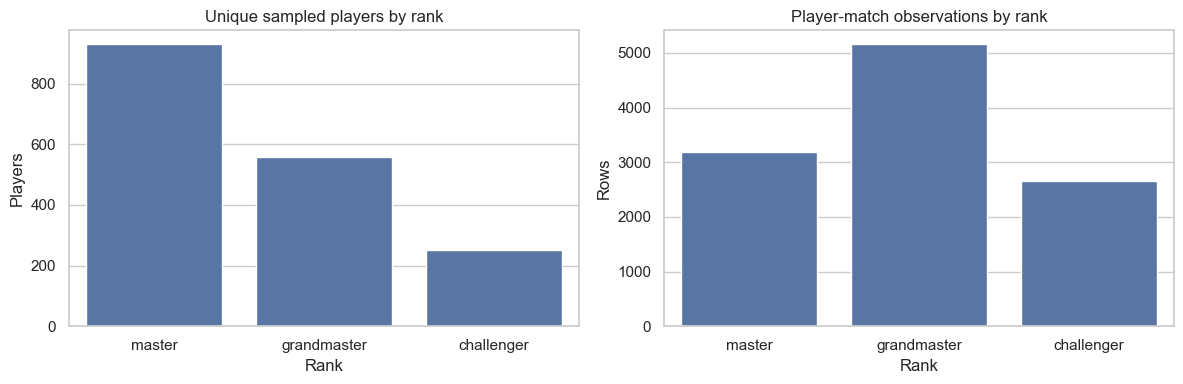

In [15]:
unique_player_ranks = df[['puuid', 'rank']].drop_duplicates()
rank_distribution = (
    unique_player_ranks.groupby('rank', observed=True)['puuid'].nunique()
    .rename('unique_players').to_frame()
    .join(df.groupby('rank', observed=True).size().rename('player_rows'))
    .assign(
        player_pct=lambda table: table['unique_players'] / table['unique_players'].sum(),
        row_pct=lambda table: table['player_rows'] / table['player_rows'].sum(),
    )
)
display_percentages(rank_distribution, ['player_pct', 'row_pct'], digits=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=rank_distribution.reset_index(), x='rank', y='unique_players', ax=axes[0])
axes[0].set(title='Unique sampled players by rank', xlabel='Rank', ylabel='Players')
sns.barplot(data=rank_distribution.reset_index(), x='rank', y='player_rows', ax=axes[1])
axes[1].set(title='Player-match observations by rank', xlabel='Rank', ylabel='Rows')
plt.tight_layout()
plt.show()

## 4. Actual win rate versus LoLalytics matchup win rate

Matchups are divided into ten similarly sized groups. Points on the dashed line would indicate that the observed player win rate matches the raw Global D2+ matchup rate.

,player_rows,mean_matchup_winrate,actual_winrate,actual_se,actual_ci_low,actual_ci_high
0,1114,43.96%,45.15%,0.015,42.23%,48.07%
1,1113,47.34%,47.89%,0.015,44.95%,50.82%
2,1077,48.73%,50.32%,0.015,47.34%,53.31%
3,1101,49.83%,51.41%,0.015,48.46%,54.36%
4,1098,50.78%,55.10%,0.015,52.16%,58.04%
5,1106,51.65%,51.99%,0.015,49.04%,54.93%
6,1093,52.53%,50.69%,0.015,47.72%,53.65%
7,1100,53.55%,54.27%,0.015,51.33%,57.22%
8,1099,54.98%,54.60%,0.015,51.65%,57.54%
9,1100,58.30%,61.55%,0.015,58.67%,64.42%


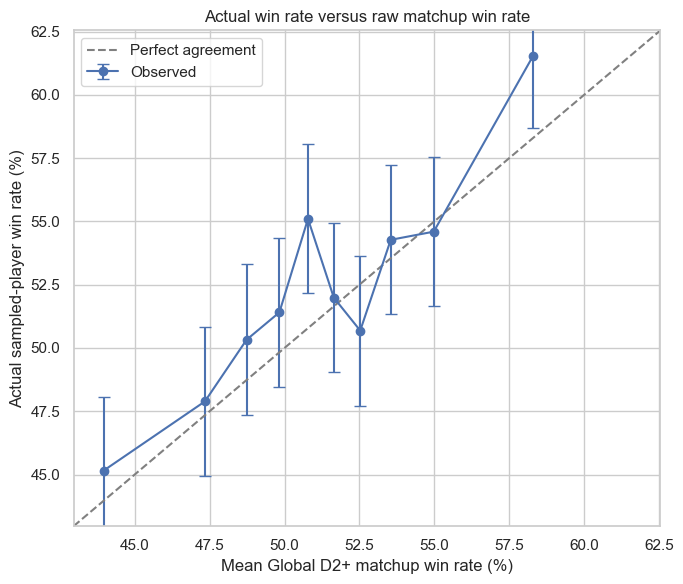

In [16]:
df['matchup_wr_decile'] = pd.qcut(df['matchup_winrate'], q=10, duplicates='drop')
calibration = (
    df.groupby('matchup_wr_decile', observed=True)
    .agg(
        player_rows=('win', 'size'),
        mean_matchup_winrate=('matchup_winrate', 'mean'),
        actual_winrate=('win', 'mean'),
    )
    .reset_index(drop=True)
)
calibration['actual_se'] = np.sqrt(
    calibration['actual_winrate'] * (1 - calibration['actual_winrate'])
    / calibration['player_rows']
)
calibration['actual_ci_low'] = calibration['actual_winrate'] - 1.96 * calibration['actual_se']
calibration['actual_ci_high'] = calibration['actual_winrate'] + 1.96 * calibration['actual_se']
display_percentages(
    calibration,
    ['mean_matchup_winrate', 'actual_winrate', 'actual_ci_low', 'actual_ci_high'],
)

x = calibration['mean_matchup_winrate'] * 100
y = calibration['actual_winrate'] * 100
yerr = calibration['actual_se'] * 1.96 * 100
lower = min(x.min(), y.min()) - 1
upper = max(x.max(), y.max()) + 1

fig, ax = plt.subplots(figsize=(7, 6))
ax.errorbar(x, y, yerr=yerr, fmt='o-', capsize=4, label='Observed')
ax.plot([lower, upper], [lower, upper], linestyle='--', color='gray', label='Perfect agreement')
ax.set(
    title='Actual win rate versus raw matchup win rate',
    xlabel='Mean Global D2+ matchup win rate (%)',
    ylabel='Actual sampled-player win rate (%)',
    xlim=(lower, upper),
    ylim=(lower, upper),
)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Results by rank

,rank,player_rows,unique_players,unique_matches,actual_winrate,average_matchup_winrate,average_otp_rate,median_player_games,winrate_gap
0,master,3191,929,1781,51.93%,51.23%,51.39%,6.000,+0.69%
1,grandmaster,5154,557,1750,51.77%,51.13%,39.31%,18.000,+0.64%
2,challenger,2656,250,994,53.73%,51.11%,30.74%,20.000,+2.61%


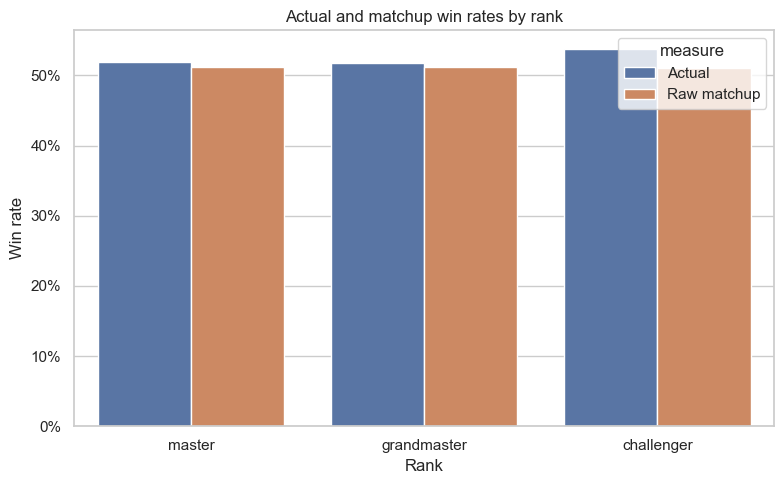

In [17]:
def summarize_groups(frame, group_columns):
    return (
        frame.groupby(group_columns, observed=True)
        .agg(
            player_rows=('win', 'size'),
            unique_players=('puuid', 'nunique'),
            unique_matches=('match_id', 'nunique'),
            actual_winrate=('win', 'mean'),
            average_matchup_winrate=('matchup_winrate', 'mean'),
            average_otp_rate=('otp_rate', 'mean'),
            median_player_games=('player_games', 'median'),
        )
        .assign(winrate_gap=lambda table: table['actual_winrate'] - table['average_matchup_winrate'])
        .reset_index()
    )

rank_results = summarize_groups(df, ['rank'])
display_percentages(
    rank_results,
    ['actual_winrate', 'average_matchup_winrate', 'average_otp_rate', 'winrate_gap'],
    signed=['winrate_gap'],
)

rank_plot = rank_results.melt(
    id_vars='rank',
    value_vars=['actual_winrate', 'average_matchup_winrate'],
    var_name='measure',
    value_name='winrate',
)
rank_plot['measure'] = rank_plot['measure'].map({
    'actual_winrate': 'Actual',
    'average_matchup_winrate': 'Raw matchup',
})
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=rank_plot, x='rank', y='winrate', hue='measure', ax=ax)
ax.yaxis.set_major_formatter(lambda value, position: f'{value:.0%}')
ax.set(title='Actual and matchup win rates by rank', xlabel='Rank', ylabel='Win rate')
plt.tight_layout()
plt.show()

## 6. Results by lane

,lane,player_rows,unique_players,unique_matches,actual_winrate,average_matchup_winrate,average_otp_rate,median_player_games,winrate_gap
0,top,1932,542,1365,52.33%,51.19%,44.54%,15.000,+1.14%
1,jungle,2195,545,1542,52.21%,51.16%,43.76%,16.000,+1.04%
2,mid,2265,567,1518,52.19%,51.02%,40.46%,18.000,+1.16%
3,adc,2356,598,1620,51.49%,51.13%,37.53%,15.000,+0.36%
4,support,2253,622,1573,53.26%,51.28%,38.22%,14.000,+1.99%


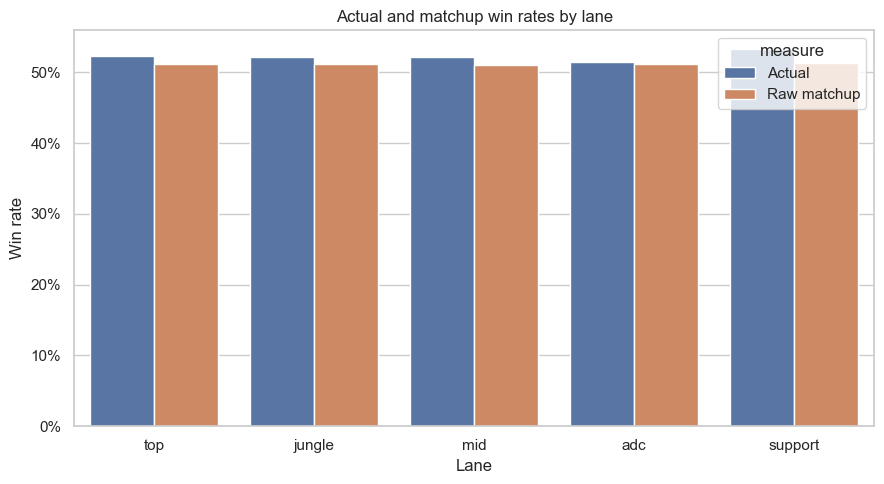

In [18]:
lane_results = summarize_groups(df, ['lane'])
display_percentages(
    lane_results,
    ['actual_winrate', 'average_matchup_winrate', 'average_otp_rate', 'winrate_gap'],
    signed=['winrate_gap'],
)

lane_plot = lane_results.melt(
    id_vars='lane',
    value_vars=['actual_winrate', 'average_matchup_winrate'],
    var_name='measure',
    value_name='winrate',
)
lane_plot['measure'] = lane_plot['measure'].map({
    'actual_winrate': 'Actual',
    'average_matchup_winrate': 'Raw matchup',
})
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=lane_plot, x='lane', y='winrate', hue='measure', ax=ax)
ax.yaxis.set_major_formatter(lambda value, position: f'{value:.0%}')
ax.set(title='Actual and matchup win rates by lane', xlabel='Lane', ylabel='Win rate')
plt.tight_layout()
plt.show()

## 7. Results by rank and lane

The first heatmap shows actual win rate. The second subtracts the average raw matchup rate; positive values mean the sampled players won more often than their matchups alone would suggest.

,rank,lane,player_rows,unique_players,unique_matches,actual_winrate,average_matchup_winrate,average_otp_rate,median_player_games,winrate_gap
0,master,top,638,243,592,50.78%,51.39%,50.68%,7.500,-0.60%
1,master,jungle,684,253,617,53.51%,51.14%,57.89%,7.000,+2.37%
2,master,mid,517,237,465,52.03%,51.08%,49.09%,6.000,+0.95%
3,master,adc,694,268,630,51.30%,51.26%,52.38%,7.000,+0.03%
4,master,support,658,279,592,51.98%,51.28%,46.09%,6.000,+0.70%
5,grandmaster,top,868,207,702,52.19%,51.07%,43.88%,16.500,+1.11%
6,grandmaster,jungle,935,195,759,51.76%,51.18%,38.87%,18.000,+0.58%
7,grandmaster,mid,1125,207,861,52.09%,51.00%,40.05%,21.000,+1.09%
8,grandmaster,adc,1055,219,853,50.43%,51.03%,35.96%,18.000,-0.60%
9,grandmaster,support,1171,244,918,52.35%,51.34%,38.61%,16.000,+1.01%


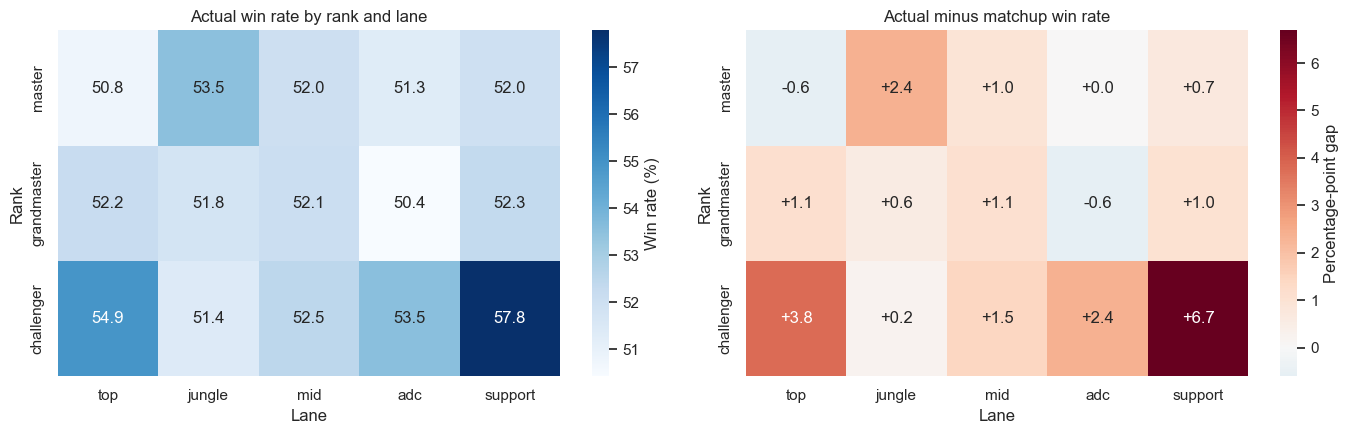

Player-row counts behind each rank/lane cell:


lane,top,jungle,mid,adc,support
rank,,,,,
master,638,684,517,694,658
grandmaster,868,935,1125,1055,1171
challenger,426,576,623,607,424


In [19]:
rank_lane_results = summarize_groups(df, ['rank', 'lane'])
display_percentages(
    rank_lane_results,
    ['actual_winrate', 'average_matchup_winrate', 'average_otp_rate', 'winrate_gap'],
    signed=['winrate_gap'],
)

actual_matrix = rank_lane_results.pivot(index='rank', columns='lane', values='actual_winrate') * 100
gap_matrix = rank_lane_results.pivot(index='rank', columns='lane', values='winrate_gap') * 100
count_matrix = rank_lane_results.pivot(index='rank', columns='lane', values='player_rows')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.heatmap(actual_matrix, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Win rate (%)'}, ax=axes[0])
axes[0].set(title='Actual win rate by rank and lane', xlabel='Lane', ylabel='Rank')
sns.heatmap(gap_matrix, annot=True, fmt='+.1f', cmap='RdBu_r', center=0, cbar_kws={'label': 'Percentage-point gap'}, ax=axes[1])
axes[1].set(title='Actual minus matchup win rate', xlabel='Lane', ylabel='Rank')
plt.tight_layout()
plt.show()

print('Player-row counts behind each rank/lane cell:')
display(count_matrix.astype('Int64'))

## 8. OTP-rate distribution and current measurement depth

These plots diagnose the provisional specialization measure. Player-game counts should improve after the next collection run.

,player_games
count,"1,736.000"
mean,7.779
std,9.102
min,1.000
10%,1.000
25%,2.000
50%,4.000
75%,11.000
90%,20.000
max,66.000


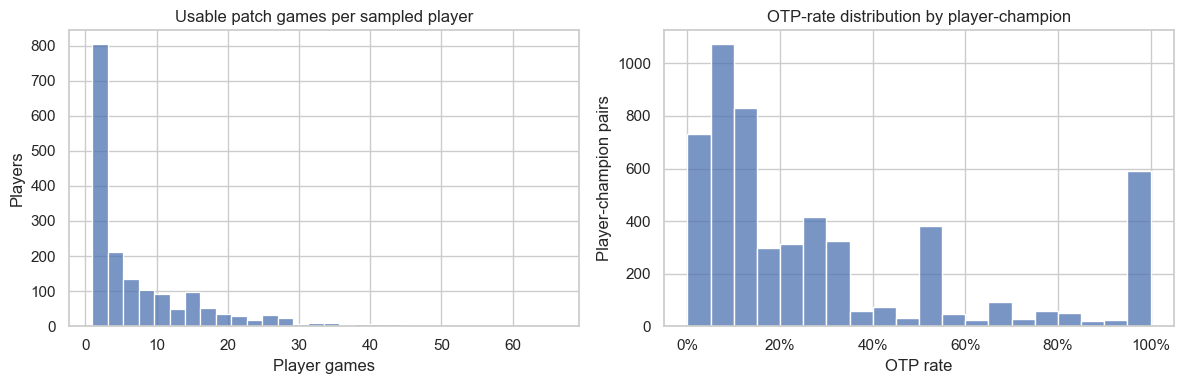

In [20]:
player_samples = df[['puuid', 'player_games']].drop_duplicates('puuid')
player_champions = df[['puuid', 'champion', 'otp_rate', 'player_games']].drop_duplicates(
    ['puuid', 'champion']
)
display(player_samples['player_games'].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).to_frame())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=player_samples, x='player_games', bins=30, ax=axes[0])
axes[0].set(title='Usable patch games per sampled player', xlabel='Player games', ylabel='Players')
sns.histplot(data=player_champions, x='otp_rate', bins=np.linspace(0, 1, 21), ax=axes[1])
axes[1].set(title='OTP-rate distribution by player-champion', xlabel='OTP rate', ylabel='Player-champion pairs')
axes[1].xaxis.set_major_formatter(lambda value, position: f'{value:.0%}')
plt.tight_layout()
plt.show()

## 9. Actual results across OTP-rate groups

This is descriptive rather than causal. Differences may reflect rank, lane, champion selection, and repeated observations from the same match or player.

,otp_rate_group,player_rows,unique_players,actual_winrate,average_matchup_winrate,median_player_games,winrate_gap
0,0–20%,4038,615,50.12%,51.04%,20.000,-0.92%
1,20–40%,2321,616,53.34%,51.09%,12.000,+2.25%
2,40–60%,1412,372,54.25%,51.13%,14.000,+3.12%
3,60–80%,1172,225,52.05%,51.17%,14.000,+0.87%
4,80–100%,2058,683,54.13%,51.46%,10.000,+2.67%


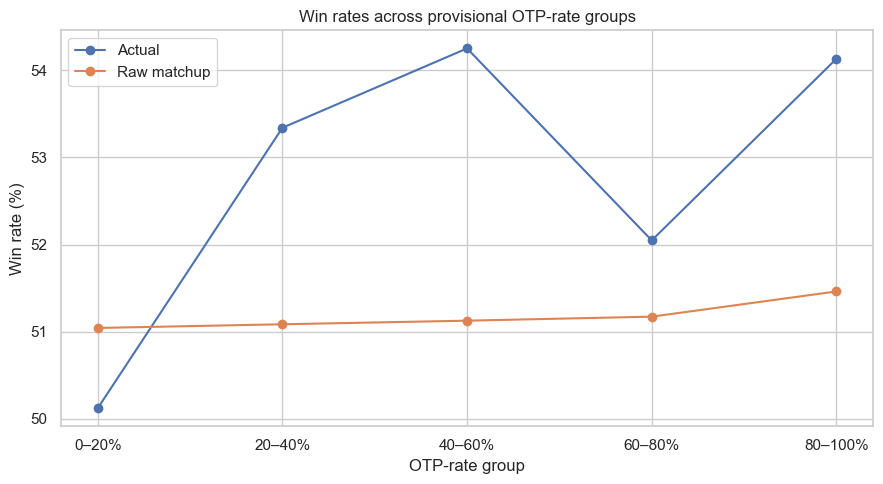

In [21]:
otp_bins = [0, 0.20, 0.40, 0.60, 0.80, 1.000001]
otp_labels = ['0–20%', '20–40%', '40–60%', '60–80%', '80–100%']
df['otp_rate_group'] = pd.cut(
    df['otp_rate'], bins=otp_bins, labels=otp_labels, include_lowest=True, right=False
)
otp_results = (
    df.groupby('otp_rate_group', observed=True)
    .agg(
        player_rows=('win', 'size'),
        unique_players=('puuid', 'nunique'),
        actual_winrate=('win', 'mean'),
        average_matchup_winrate=('matchup_winrate', 'mean'),
        median_player_games=('player_games', 'median'),
    )
    .assign(winrate_gap=lambda table: table['actual_winrate'] - table['average_matchup_winrate'])
    .reset_index()
)
display_percentages(
    otp_results,
    ['actual_winrate', 'average_matchup_winrate', 'winrate_gap'],
    signed=['winrate_gap'],
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(otp_results['otp_rate_group'].astype(str), otp_results['actual_winrate'] * 100, marker='o', label='Actual')
ax.plot(otp_results['otp_rate_group'].astype(str), otp_results['average_matchup_winrate'] * 100, marker='o', label='Raw matchup')
ax.set(title='Win rates across provisional OTP-rate groups', xlabel='OTP-rate group', ylabel='Win rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Side balance

,side,player_rows,unique_players,unique_matches,actual_winrate,average_matchup_winrate,average_otp_rate,median_player_games,winrate_gap
0,blue,5374,1423,2337,49.67%,51.07%,41.17%,15.000,-1.40%
1,red,5627,1404,2416,54.79%,51.24%,40.34%,16.000,+3.55%


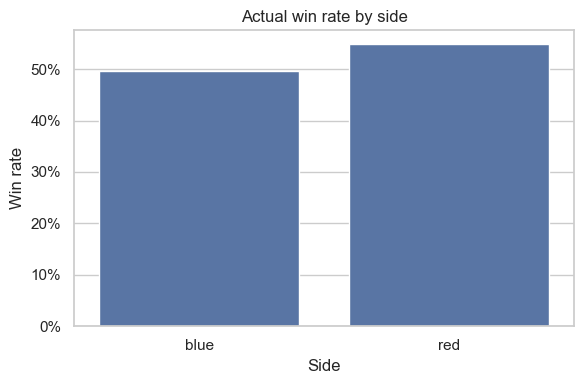

In [22]:
side_results = summarize_groups(df, ['side'])
display_percentages(
    side_results,
    ['actual_winrate', 'average_matchup_winrate', 'average_otp_rate', 'winrate_gap'],
    signed=['winrate_gap'],
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=side_results, x='side', y='actual_winrate', ax=ax)
ax.yaxis.set_major_formatter(lambda value, position: f'{value:.0%}')
ax.set(title='Actual win rate by side', xlabel='Side', ylabel='Win rate')
plt.tight_layout()
plt.show()

## 11. Collection coverage over time

,game_date,player_rows,unique_matches,actual_winrate
0,Sep 23,3031,733,52.26%
1,Sep 24,3099,745,52.57%
2,Sep 25,3343,827,52.71%
3,Sep 26,1528,396,50.85%


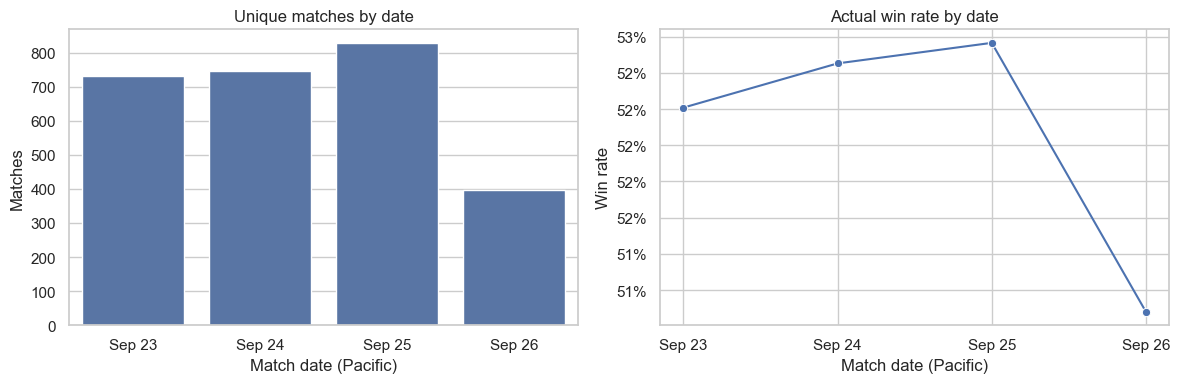

In [23]:
df['game_date'] = df['game_start_time'].dt.strftime('%b %d')
daily_results = (
    df.groupby('game_date', sort=False)
    .agg(
        player_rows=('win', 'size'),
        unique_matches=('match_id', 'nunique'),
        actual_winrate=('win', 'mean'),
    )
    .reset_index()
)
display_percentages(daily_results, ['actual_winrate'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=daily_results, x='game_date', y='unique_matches', ax=axes[0])
axes[0].set(title='Unique matches by date', xlabel='Match date (Pacific)', ylabel='Matches')
sns.lineplot(data=daily_results, x='game_date', y='actual_winrate', marker='o', ax=axes[1])
axes[1].yaxis.set_major_formatter(lambda value, position: f'{value:.0%}')
axes[1].set(title='Actual win rate by date', xlabel='Match date (Pacific)', ylabel='Win rate')
plt.tight_layout()
plt.show()

## 12. Most represented champions

This is a coverage diagnostic—not a champion-strength ranking.

,champion,player_rows,unique_players,actual_winrate
0,Yunara,256,121,49.61%
1,Jhin,227,109,44.93%
2,Viktor,218,92,53.67%
3,Yone,218,104,53.21%
4,LeeSin,214,86,42.52%
5,Qiyana,206,62,53.88%
6,Syndra,204,96,55.88%
7,Janna,196,60,52.55%
8,Nautilus,162,95,54.94%
9,Chogath,155,68,51.61%


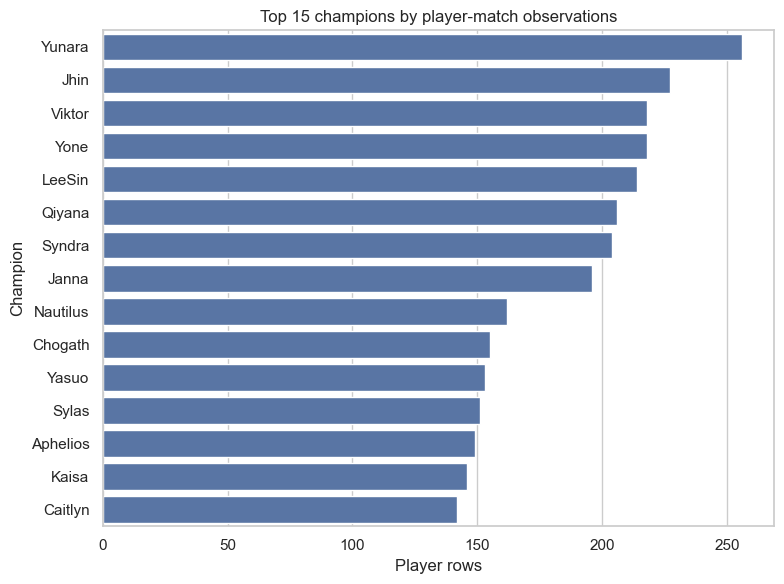

In [24]:
top_champions = (
    df.groupby('champion')
    .agg(player_rows=('win', 'size'), unique_players=('puuid', 'nunique'), actual_winrate=('win', 'mean'))
    .sort_values('player_rows', ascending=False)
    .head(15)
    .reset_index()
)
display_percentages(top_champions, ['actual_winrate'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=top_champions, y='champion', x='player_rows', ax=ax)
ax.set(title='Top 15 champions by player-match observations', xlabel='Player rows', ylabel='Champion')
plt.tight_layout()
plt.show()

## Interpretation reminders

- These figures are descriptive; they do not isolate the effect of specialization.
- Multiple rows can come from the same match and the same player. Modeling should split by `match_id` and use match-clustered uncertainty.
- `otp_rate` is currently based on a short patch window. Rerun this notebook after expanding the Riot collection next weekend.
- The primary model should control for raw matchup win rate, rank, lane, and side before interpreting the OTP-rate coefficient.